In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
%cd /content/drive/MyDrive/Colab Notebooks/Random Projects/Customer Segmentation Using Clustering

/content/drive/MyDrive/Colab Notebooks/Random Projects/Customer Segmentation Using Clustering


In [41]:
!apt install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [42]:
!git config --global user.name "itsarbababdurrab"
!git config --global user.email "arbabz2001@gmail.com"

In [43]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Colab Notebooks/Random Projects/Customer Segmentation Using Clustering/.git/


In [45]:
!git remote add origin https://github.com/itsarbababdurrab/-customer-segmentation-using-clustering.git

In [46]:
!git add .

In [47]:
!git commit -m "Customer Segmentation using Clustering"

[master (root-commit) 310c7da] Customer Segmentation using Clustering
 2 files changed, 202 insertions(+)
 create mode 100644 Customer_Segmentation_Using_Clustering.ipynb
 create mode 100644 Mall_Customers.csv


In [52]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Random Projects/Customer Segmentation Using Clustering/Mall_Customers.csv')

In [24]:
# Display first few rows
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [25]:
# Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [26]:
# Summary statistics
display(df.describe())

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [27]:
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [28]:
# Selecting relevant features
X = df.iloc[:, [2, 3, 4]].values  # Assuming Age, Annual Income, and Spending Score

In [29]:
# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# K-Means Clustering
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

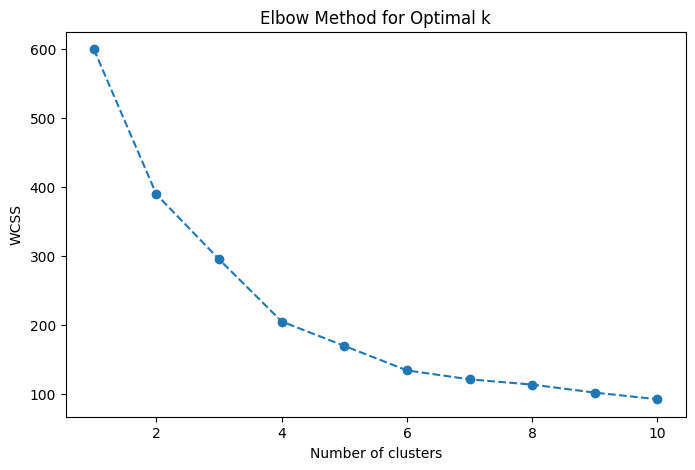

In [31]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

In [32]:
# Applying K-Means with optimal clusters (let's assume k=5 from the elbow method)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

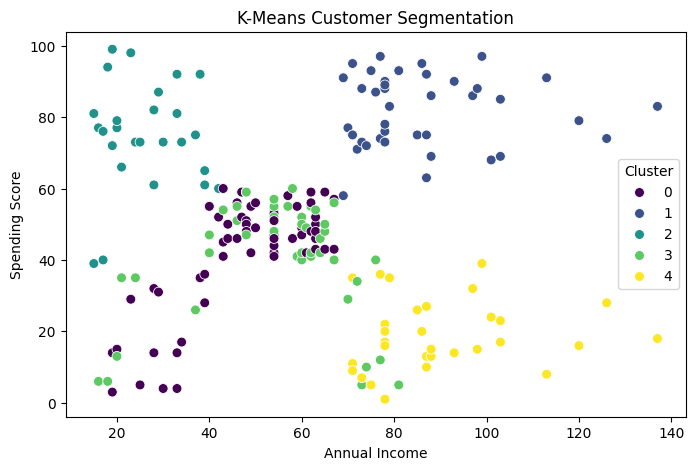

In [33]:
# Visualizing K-Means Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 1], y=X[:, 2], hue=df['Cluster'], palette='viridis', s=50)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Means Customer Segmentation')
plt.show()

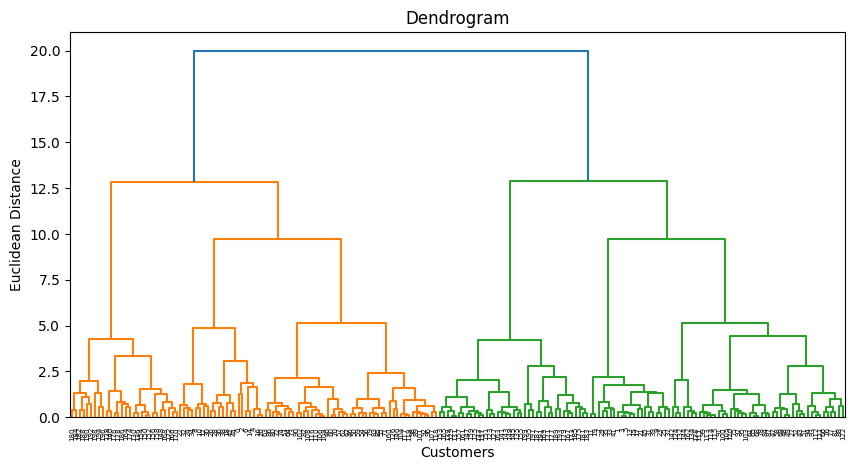

In [34]:
# Hierarchical Clustering
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

In [35]:
# Applying Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=5,  linkage='ward')
y_hc = hc.fit_predict(X_scaled)

df['HCluster'] = y_hc

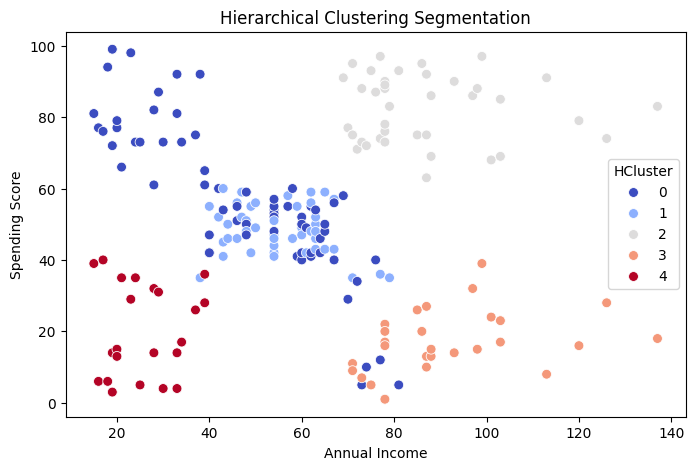

In [36]:
# Visualizing Hierarchical Clustering
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 1], y=X[:, 2], hue=df['HCluster'], palette='coolwarm', s=50)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Hierarchical Clustering Segmentation')
plt.show()

In [37]:
# Display the final dataframe
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,HCluster
0,1,Male,19,15,39,2,4
1,2,Male,21,15,81,2,0
2,3,Female,20,16,6,3,4
3,4,Female,23,16,77,2,0
4,5,Female,31,17,40,2,4
